In [ ]:
import os 
import json 

from pyddeeg.classification import EEGDataset
from pyddeeg.classification.engine.trainer import evaluate_frozen_models

from pathlib import Path

from sklearn.ensemble import HistGradientBoostingClassifier

PATH_OPTIMIZED = "/home/mariopasc/Python/Results/EEG/T7_window_1000_up"
with open(os.path.join(PATH_OPTIMIZED, "best_params.json"), 'r') as f:
    params = json.load(f)  # parse JSON into native Python objects

ds_root = Path("/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset")
window = "window_1000"
direction = "up"
seed = 42
elec = "T7"
base_estimator = HistGradientBoostingClassifier



dataset = EEGDataset.load(ds_root, window, direction, elec, random_state=seed)


results = evaluate_frozen_models(
    dataset=dataset,
    params_per_window=params,  
    base_estimator_cls=base_estimator,
    n_jobs_windows=10
)

/home/mariopasc/Python/misc/miniconda3/envs/pyddeeg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Folds: 100%|██████████| 5/5 [00:12<00:00,  2.47s/fold]


(<Figure size 1200x700 with 2 Axes>,
 (<Axes: title={'center': 'Fold-wise ROC-AUC over time'}, ylabel='AUC'>,
  <Axes: title={'center': 'Selected features per window (1=selected)'}, xlabel='Time (s)', ylabel='RQA Metric'>))

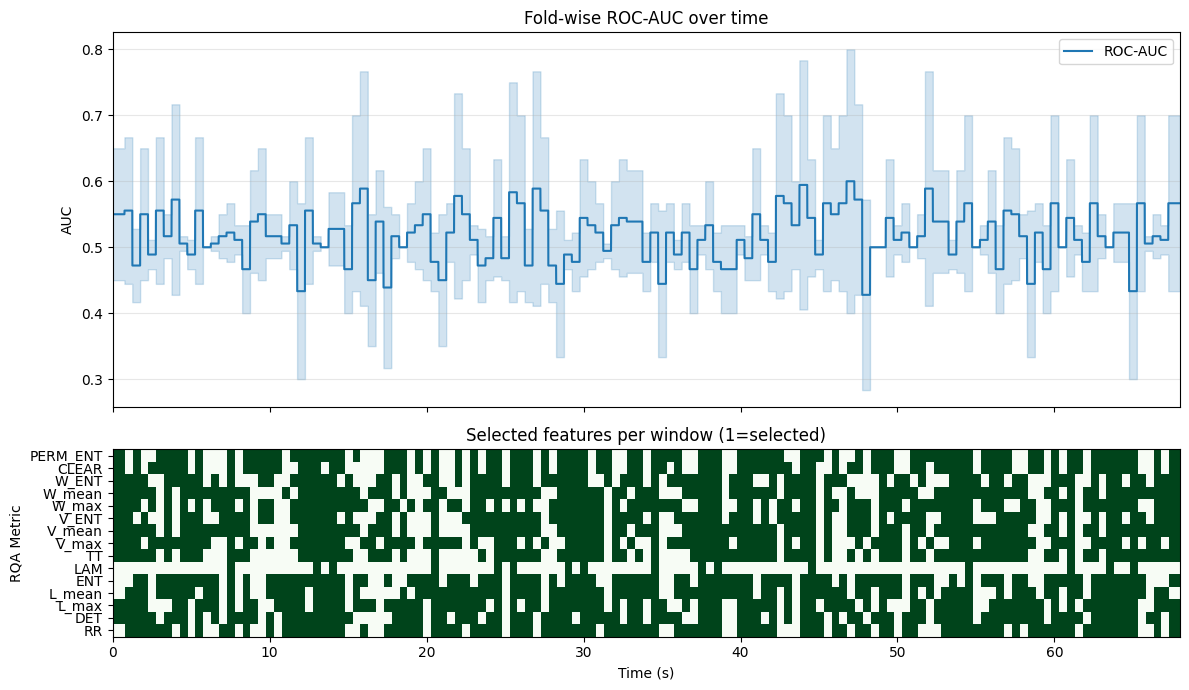

In [3]:
from pyddeeg.classification.utils.basic_visualizations import plot_auc_and_selected_features

plot_auc_and_selected_features(results=results, dataset=dataset, show_colorbar=False)

In [10]:
from pyddeeg.classification.engine.trainer import permutation_test_decision_scores

permutation_results = permutation_test_decision_scores(decision_scores=results["decision_scores"],
                                 labels=results["labels"], n_permutations=10000)

Using a threshold of 4.047100
stat_fun(H1): min=2.1508015899747888e-06 max=6.988033781663765
Running initial clustering …
Found 5 clusters


100%|██████████| Permuting : 9999/9999 [00:00<00:00, 14046.77it/s]


In [10]:
ds_root = Path("/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset")
import json
json_path = (ds_root / 'dataset_index.json')
# Load json
with open(json_path, 'r') as f:
    dataset_index = json.load(f)
dataset_index["window_1000"]["up"]

{'C4': ['/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/window_1000/up/C4_DD_UP.npz',
  '/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/window_1000/up/C4_CT_UP.npz'],
 'F7': ['/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/window_1000/up/F7_CT_UP.npz',
  '/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/window_1000/up/F7_DD_UP.npz'],
 'P8': ['/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/window_1000/up/P8_CT_UP.npz',
  '/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/window_1000/up/P8_DD_UP.npz'],
 'FC5': ['/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/window_1000/up/FC5_DD_UP.npz',
  '/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/window_1000/up/FC5_CT_UP.npz'],
 'PO9': ['/home/mariopasc/Python/Datasets/EEG/timeseries/processed/rqa_windows/dataset/wi